# Penguin Linear Regression by Off-the-shelf polyfit

In [3]:
# read the variables: class label and features

def string2float(item):
    return float(item) if item != '' else None

def read_strings(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[col] for line in lines[1:]]
    return values

def read_floats(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[col]) for line in lines[1:]]
    return values

In [5]:
filename = 'data/palmer-penguins/palmer-penguins-train.txt'

species = read_strings(filename, col=0)

islands = read_strings(filename, col=1)

bill_lengths = read_floats(filename, col=2)
bill_depths = read_floats(filename, col=3)
flipper_lengths =  read_floats(filename, col=4)

body_masses = read_floats(filename, col=5)

print('        species:', species[::20])
print('        islands:', islands[::20])
print('   bill lengths:', bill_lengths[::20])
print('    bill depths:', bill_depths[::20])
print('flipper lengths:', flipper_lengths[::20])
print('    body masses:', body_masses[::20])

        species: ['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Chinstrap']
        islands: ['Torgersen', 'Dream', 'Torgersen', 'Torgersen', 'Biscoe', 'Biscoe', 'Biscoe', 'Dream', 'Dream']
   bill lengths: [39.1, 36.5, 34.6, 36.2, 43.3, 44.9, 47.5, 52.7, 50.9]
    bill depths: [18.7, 18.0, 17.2, 17.2, 13.4, 13.3, 14.0, 19.8, 17.9]
flipper lengths: [181.0, 182.0, 189.0, 187.0, 209.0, 213.0, 212.0, 197.0, 196.0]
    body masses: [3750.0, 3150.0, 3200.0, 3150.0, 4400.0, 5100.0, 4875.0, 3725.0, 3675.0]


In [7]:
def get_grouped_items(items, species,
                      target_species_names=('Adelie', 'Chinstrap', 'Gentoo')):
    data = dict()
    for target_species_name in target_species_names:
        data[target_species_name] = [items[idx] for idx, species_name in enumerate(species)
                                     if species_name == target_species_name]
    return data

def inspect_dict(d, n=5):
    for key in d:
        print(key, ':', d[key][:n])

In [9]:
islands_dict = get_grouped_items(islands, species)
inspect_dict(islands_dict)

bill_lengths_dict = get_grouped_items(bill_lengths, species)
bill_depths_dict = get_grouped_items(bill_depths, species)
flipper_lengths_dict = get_grouped_items(flipper_lengths, species)
body_masses_dict = get_grouped_items(body_masses, species)

Adelie : ['Torgersen', 'Torgersen', 'Torgersen', 'Torgersen', 'Torgersen']
Chinstrap : ['Dream', 'Dream', 'Dream', 'Dream', 'Dream']
Gentoo : ['Biscoe', 'Biscoe', 'Biscoe', 'Biscoe', 'Biscoe']


In [11]:
import matplotlib.pyplot as plt

def plot_overlapping_histgrams(data, xlabel=''):
    for key in data: # loop in dict
        plt.hist(data[key], alpha=0.5, bins=20, label=key)
    plt.xlabel(xlabel)

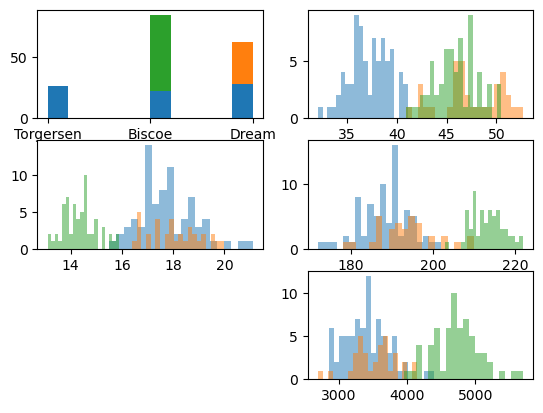

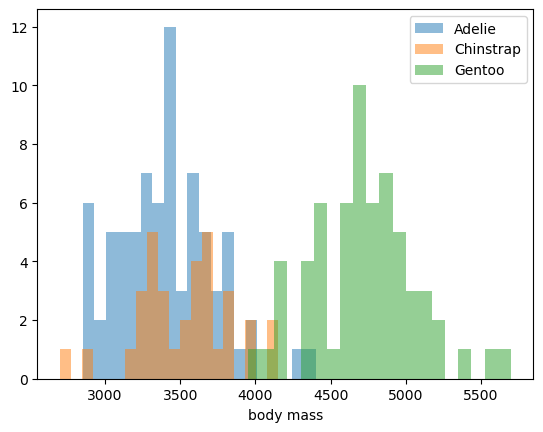

In [13]:
plt.figure()

plt.subplot(321)
h = plt.hist([islands_dict['Adelie'],
              islands_dict['Chinstrap'],
              islands_dict['Gentoo']],
             stacked=True)

plt.subplot(322)
plot_overlapping_histgrams(bill_lengths_dict)

plt.subplot(323)
plot_overlapping_histgrams(bill_depths_dict)

plt.subplot(324)
plot_overlapping_histgrams(flipper_lengths_dict)

plt.subplot(326)
plot_overlapping_histgrams(body_masses_dict)

plt.figure()
plot_overlapping_histgrams(body_masses_dict)
plt.xlabel('body mass')
plt.legend(loc='upper right')

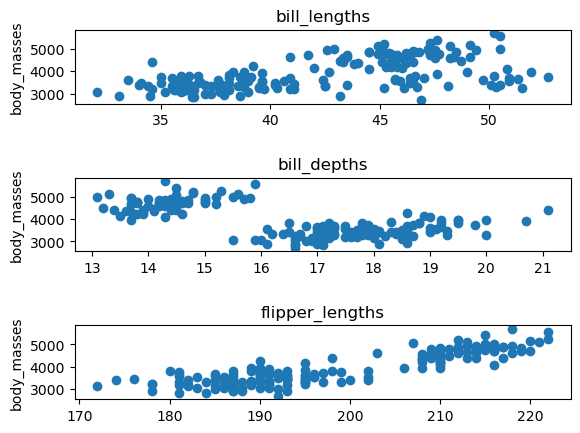

In [15]:
import matplotlib.pyplot as plt

plt.figure()

plt.subplot(311)
plt.scatter(bill_lengths, body_masses)
plt.title('bill_lengths')
plt.ylabel('body_masses')

plt.subplot(312)
plt.scatter(bill_depths, body_masses)
plt.title('bill_depths')
plt.ylabel('body_masses')

plt.subplot(313)
plt.scatter(flipper_lengths, body_masses)
plt.title('flipper_lengths')
plt.ylabel('body_masses')

plt.subplots_adjust(hspace=1)

w: 47.47266270397305 b: -5505.904326983398


(2700.0, 5700.0)

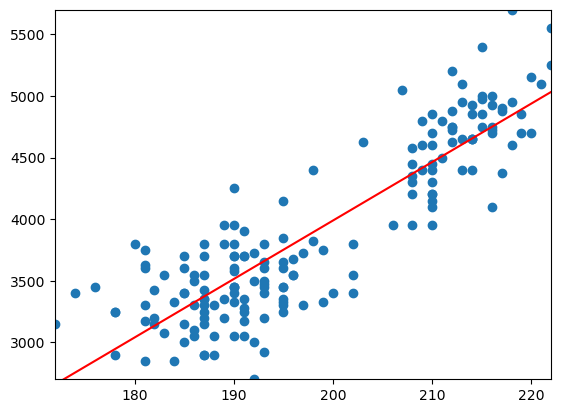

In [17]:
# off the shelf linear regression model

import numpy as np

# body_mass = w * flipper_length + b
w, b = np.polyfit(flipper_lengths, body_masses, deg=1)
print('w:', w, 'b:', b)

plt.scatter(flipper_lengths, body_masses)

plt.axline(xy1=(0, b), slope=w, color='red')

plt.xlim(np.min(flipper_lengths), np.max(flipper_lengths))
plt.ylim(np.min(body_masses), np.max(body_masses))

In [41]:
# evaluation on training data

import math

total_squared_error = 0.0

num_data = len(flipper_lengths)

for idx in range(num_data):
    flipper_length = flipper_lengths[idx]
    body_mass = body_masses[idx]
    predicted_body_mass = w * flipper_length + b
    squared_error = (body_mass - predicted_body_mass) ** 2
    total_squared_error += squared_error

mse = total_squared_error / num_data
print('mean squared error:', mse)

import numpy as np

print(np.mean(body_masses), math.sqrt(mse),
      math.sqrt(mse)/np.mean(body_masses))

mean squared error: 112607.97613696936
3903.343023255814 335.5711193427846 0.0859701843633721


(2975.0, 6300.0)

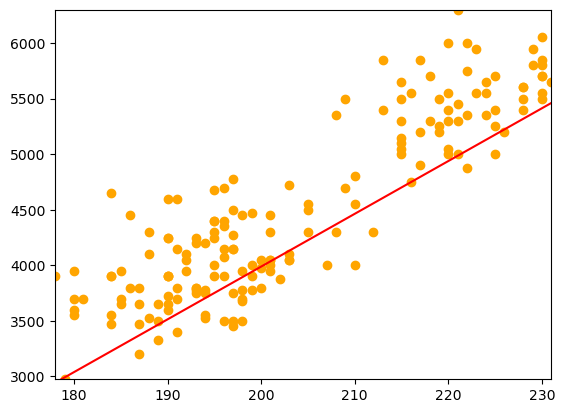

In [37]:
# test data

filename = 'data/palmer-penguins/palmer-penguins-test.txt'

test_flipper_lengths =  read_floats(filename, col=4)
test_body_masses = read_floats(filename, col=5)

plt.scatter(test_flipper_lengths, test_body_masses, color='orange')

plt.axline(xy1=(0, b), slope=w, color='red')

x_values = [value for value in test_flipper_lengths if value is not None]
y_values = [value for value in test_body_masses if value is not None]

plt.xlim(np.min(x_values), np.max(x_values))
plt.ylim(np.min(y_values), np.max(y_values))

In [49]:
# evaluation on test data

import math

total_squared_error = 0.0
total_body_mass = 0.0

num_data = 0
for flipper_length, body_mass in zip(test_flipper_lengths, test_body_masses):
    if flipper_length is not None and body_mass is not None:
        num_data += 1
        total_body_mass += body_mass
        predicted_body_mass = w * flipper_length + b
        squared_error = (body_mass - predicted_body_mass) ** 2
        total_squared_error += squared_error

mse = total_squared_error / num_data
print('mean squared error:', mse)

import numpy as np

mean_body_mass = total_body_mass / num_data
print(mean_body_mass, math.sqrt(mse),
      math.sqrt(mse)/mean_body_mass)

mean squared error: 256840.66721462348
4503.676470588235 506.79450195776934 0.11252906492450063
